# HW 3 Regression's Feature Selection with Ant Colony method and Gradient Boosting

## Dataset description

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026")

print("Path to dataset files:", path)

100%|██████████| 1.31M/1.31M [00:00<00:00, 66.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026/versions/1


Электронная коммерция (E-commerce) и аналитика розничных онлайн-продаж. Данные отражают активность покупателей и историю транзакций за 6 лет (период с 2020 по 2026 год) по 20 странам и 14 категориям товаров.

Данные распределены по нескольким таблицам, но базовой для анализа поведения клиентов является customers.csv (8000 объектов, 20 столбцов)

Основные группы признаков:
- Демографические метрики: country (страна проживания клиента), age (возраст), gender (пол: Male / Female / Other).

- Профиль лояльности: membership_tier (уровень подписки: Free, Silver, Gold, Platinum), registration_date (дата создания аккаунта).

- Поведенческие факторы и RFM-анализ: total_orders (общее число заказов), days_since_last_purchase (показатель Recency — сколько дней назад был совершен последний заказ).

- Взаимодействие и фидбек: avg_review_score (средняя оценка товаров от 1 до 5), returns_made (количество оформленных возвратов).

- Финансовые маркеры: total_spend_usd (суммарные траты) и avg_order_value_usd (средний чек).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as md
%matplotlib inline
plt.style.use('bmh'); sns.set_style("whitegrid")
plt.rc('xtick', labelsize=15); plt.rc('ytick', labelsize=15)
import warnings
warnings.simplefilter(action='ignore')

df = pd.read_csv(f"{path}/customers.csv")

In [4]:
df.head()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   object 
 1   country                   8000 non-null   object 
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   object 
 4   membership_tier           8000 non-null   object 
 5   registration_date         8000 non-null   object 
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   object 
 11  preferred_device          8000 non-null   object 
 12  preferred_payment_method  8000 non-null   object 
 13  acquisition_channel       8000 non-null   object 
 14  reviews_

In [6]:
df.describe()

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,16.545250,1558.642350,94.845566,59.583875,3.228750,4.109112,0.849500,4.457125,0.617375,0.089375
std,11.170455,14.681064,2284.094953,78.992885,60.610355,3.942698,0.523992,1.407337,4.854391,0.486058,0.285302
min,18.000000,1.000000,4.890000,5.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,5.000000,336.055000,44.690000,16.000000,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000
50%,35.000000,12.000000,845.700000,72.270000,41.000000,2.000000,4.200000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,23.000000,1892.165000,118.560000,84.000000,5.000000,4.500000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,1051.730000,582.000000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000


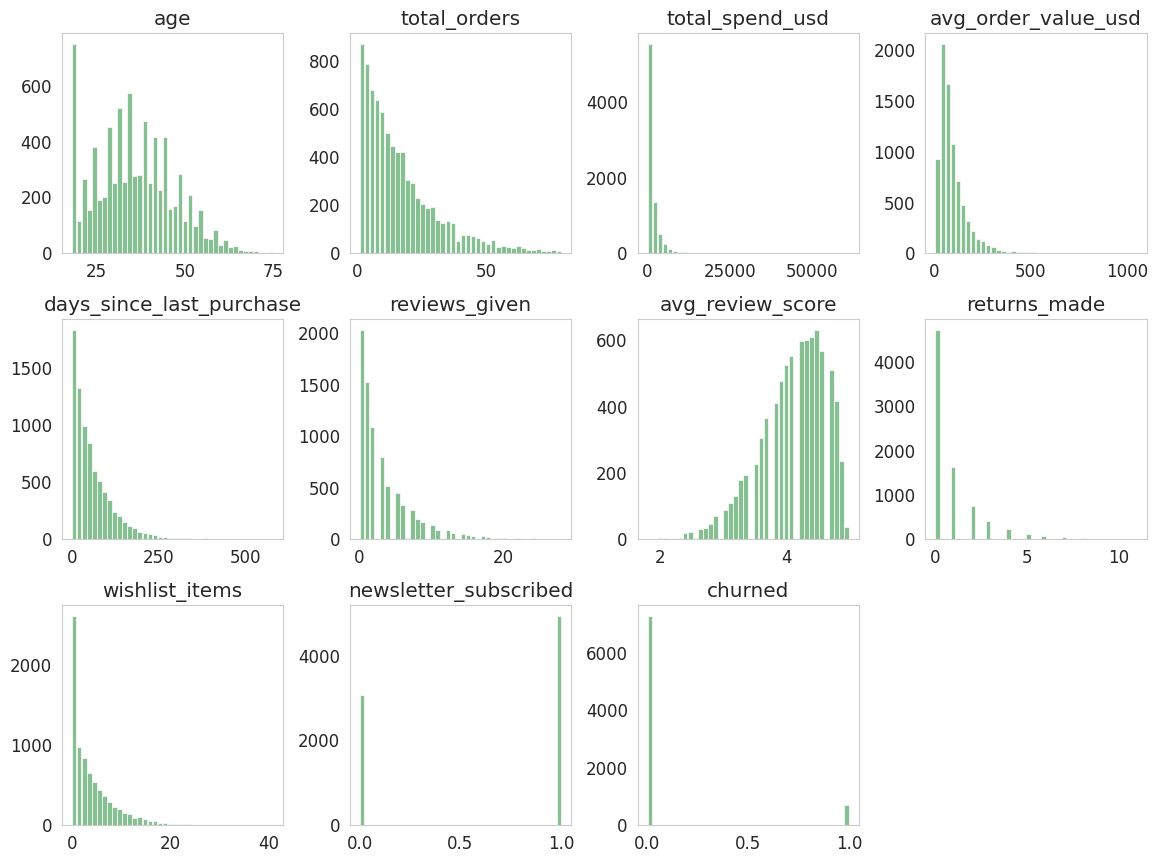

In [7]:
ax = df.hist(bins=40, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91',
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

## Data preprocessing

- по результатам `df.describe()` заметно, что выборка в датасете уже заметно отфильтрована и не имеет значений, которые противоречили бы доменам
- по результатам построения диаграмм вызывают подозрения распределения age и total_orders, они могут быть вызваны вмешательством в процессе предподготовки данных или характером разбиения на корзины данных, однако методы должны будут отклонить такие столбцы, ведь если данные плохие, то они не будут определять результат

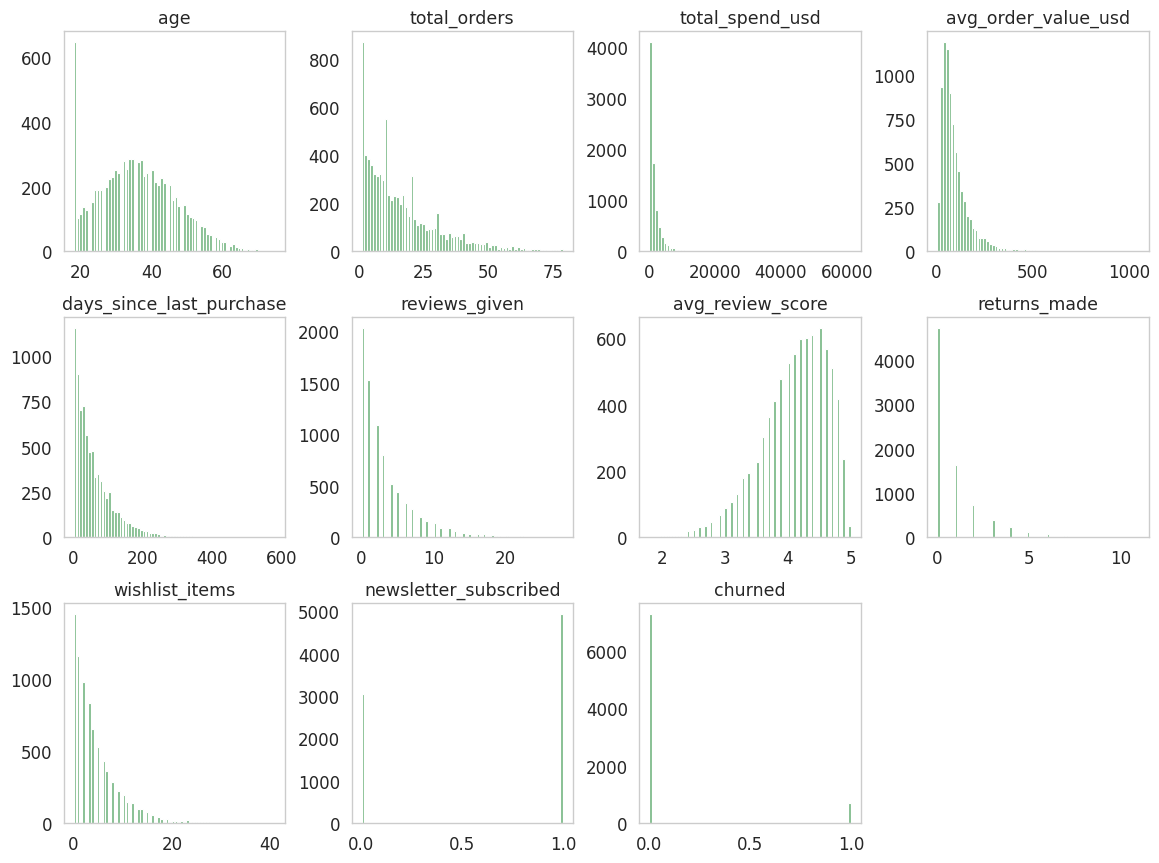

In [27]:
ax = df.hist(bins=70, grid=False, figsize=(14,14), layout=(4,4), color='#86bf91',
                      zorder=2, rwidth=0.9, xlabelsize=12, ylabelsize=12)

- можно заметить, что расчёска сместилась, поэтому кажется необязательным её учитывать как странность в распределении данных

### Divide dataset

In [29]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

TARGET = 'total_spend_usd'
FEATURES = [col for col in df.columns if col != TARGET]
NUM_FEATURES = df[FEATURES].select_dtypes(include=np.number).columns.tolist()

x_train = df[NUM_FEATURES].copy()
y_train = df[TARGET].copy()

x_scaler = MinMaxScaler()
x_scaler.fit(x_train)

all_scaler = MinMaxScaler()
all_scaler.fit(df[NUM_FEATURES])
all_scaled = all_scaler.transform(df[NUM_FEATURES])

print(f"shape of x_train (numerical features only, scaled): {x_train.shape}")
print(f"original df shape: {df.shape}")

shape of x_train (numerical features only, scaled): (8000, 10)
original df shape: (8000, 20)


### Feature Importance 1. Градиентный бустинг

In [30]:
import pickle
from sklearn import ensemble

params = {
    "n_estimators": 300,
    "max_depth": 4,
    "min_samples_split": 10,
    "learning_rate": 0.01,
    "verbose": 0,#1,
}
model_base_full = ensemble.GradientBoostingRegressor(**params)
model_base_full.fit(x_train, y_train)


GradientBoostingRegressor(learning_rate=0.01, max_depth=4, min_samples_split=10,
                          n_estimators=300)

In [31]:
N_FEATURES = 7

[2 1 4 5 0 6 3]


<Axes: xlabel='Vals', ylabel='Name'>

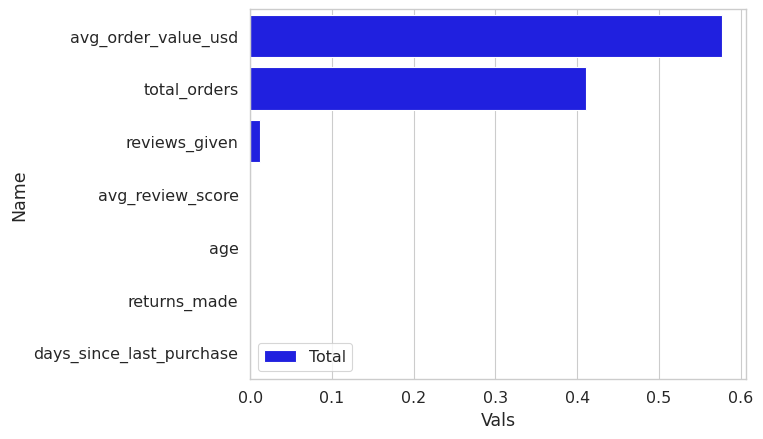

In [32]:
import copy
base_feature_importance = copy.deepcopy(model_base_full.feature_importances_)
base_feature_importance_sorted_idx = np.argsort(base_feature_importance)[::-1]
base_feature_importance_sorted_idx = base_feature_importance_sorted_idx[0:N_FEATURES]
print(base_feature_importance_sorted_idx)

boosting_names = [NUM_FEATURES[i] for i in base_feature_importance_sorted_idx]
vals = base_feature_importance[base_feature_importance_sorted_idx]
fimps = pd.DataFrame(data={'Name': boosting_names, 'Vals':vals})

sns.set_context("paper", font_scale=1.3)
sns.barplot(x="Vals", y="Name", data=fimps, label="Total", color="b", )


### Feature Importance 2. Муравьиная колония (UFSACO)

In [33]:
# Малое число
EPS = 1e-6
# Первоначальное число признаков
N_START_FEATURES = all_scaled.shape[1]
print(N_START_FEATURES)
# Итоговое число признаков
N_END_FEATURES = 7
# Максимально число циклов
NC_MAX = 3
# Число шагов внутри цикла
N_STEPS = 4
# Начальное количество феромона
INIT_PHEROMONE = 0.2
# коэффициент испарения
RO = 0.2
# Вероятность выполнения шага применения (exploitation)
EXPLOITATION_PROB = 0.7
# Параметры относительной важности некоррелированности выбираемых фичей и коррелированности с таргетом относительно желательности фичи.
ALPHA = 1.0
BETA = 1.0
# Число агентов
N_ANTS = 5

10


In [34]:
sim = {}
def set_sim(i, j):
    a = all_scaled[:, i]
    b = all_scaled[:, j]
    res = np.dot(np.asarray(a), np.asarray(b)) / (np.linalg.norm(a) * np.linalg.norm(b))
    sim[(min(i, j), max(i, j))] = np.abs(res)
    return res

def get_sim(i, j):
    (i, j) = (min(i, j), max(i, j))
    if (i, j) not in sim.keys():
        set_sim(i, j)
    return sim[(i, j)]





Цикл по этапам перераспределения: count = 0;NC_MAX=3:

    ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau)) # tau - ферромон

    nodes_visited = {(k, i): set()}

    Цикл по длине пути муравья от старта: iter = 0;4:

        Цикл по номерам муравьёв: k=0;5:

            i = ants_pos[k] # номер фичи i, последней для k-го муравья   

            node_score = [tau[j]/cos(i-ая, j-ая фичи) for j in unvisited]

              # подобрать номер фичи jj из unvisited по EXPLORATION / EXPLOITATION
              (Random on distr / ArgMax{node_score}) j = unvisited[jj]

            ants_pos[k] = j     

            nodes_visited[(k, i)].add(j)

    Пересчёт ферромона: tau = (1 - RO) * tau + (visits / total_visits)  # посещения только с текущего этапа
        

In [35]:
def UFSACO(verbose=True):
    # Инициируем начальным значением феромона в каждом узле
    tau = INIT_PHEROMONE * np.ones((N_START_FEATURES))

    #np.random.seed(1234)
    # Внешний цикл - число эпох
    for count in range(NC_MAX):
        # случайно размещаем муравьёв по узлам с вероятностью, пропорциональной феромону
        ants_pos = np.random.choice(N_START_FEATURES, size=N_ANTS, p=tau/sum(tau))
        # print(ants_pos)

        # Очищаем счётчик посещений узлов для каждого узла
        visits = np.zeros((N_START_FEATURES))

        # Очищаем множество посещённых узлов каждым k-ым агентом из каждого i-ого узла
        nodes_visited = {(k, i): set() for k in range(N_ANTS) for i in range(N_START_FEATURES)}

        # внутренний цикл - длина пути, который проходят все муравьи
        for iter in range(N_STEPS):
            # k - номер текущего муравья
            # самый внутренний - шаг одного муравья
            for k in range(N_ANTS):
                # на каком узле i-ом узле находится k-ый муравей
                i = ants_pos[k]
                # print(i)
                # множество посещённых узлов
                visited = nodes_visited[(k, i)]
                # print(visited)
                # множество непосещённых узлов
                unvisited = list((set(range(N_START_FEATURES)) - visited) - {i})
                # print(unvisited)

                # массив "желательности" узла

                # 1) UFSACO: без учёта таргета
                #print([get_sim(i, j) for j in unvisited])
                node_score = [tau[j] / np.power(get_sim(i, j), ALPHA) for j in unvisited]
                #print(node_score)

                # какой шаг выполняем - exploration или exploitation?
                q = np.random.uniform()
                # print(q)
                if q <= EXPLOITATION_PROB:
                    # EXPLOITATION
                    if verbose:
                        print("EXPLOITATION")
                    # переходим в узел с максомальной желательностью
                    jj = np.argmax(node_score)
                else:
                    # EXPLORATION
                    if verbose:
                        print("EXPLORATION")
                    # переходим по вероятности, пропорциональной желательности
                    p = node_score / sum(node_score)
                    jj = np.random.choice(len(unvisited), size=1, p=p)[0]
                # получаем номер следущего узла j для k: i -> j
                j = unvisited[jj]
                # перемещаем k-ого муравья в j-ый узел
                ants_pos[k] = j
                # добавляем информацию о перемещении
                nodes_visited[(k, i)].add(j)
                # увеличиваем счётчик посещения j-ого узла
                visits[j] += 1
                if verbose:
                    print(f"count={count}, iter={iter}, k={k}, i={i}, j={j}")
        # пересчитываем количество феромона
        total_visits = sum(visits)
        tau = (1 - RO) * tau + (visits / total_visits)
    return tau

### Запустим алгоритм 5 раз и оценим устойчивость при выбранных значениях гиперпараметров

In [41]:
# all_input_names = [TARGET,] + NUM_FEATURES
all_input_names = NUM_FEATURES

for a in range(5):
    features_UFSACO = np.array(UFSACO(verbose=False).argsort()[::-1][0:N_END_FEATURES])
    names = [all_input_names[i] for i in features_UFSACO]
    print(names)

['churned', 'returns_made', 'reviews_given', 'wishlist_items', 'days_since_last_purchase', 'avg_order_value_usd', 'newsletter_subscribed']
['churned', 'returns_made', 'newsletter_subscribed', 'reviews_given', 'wishlist_items', 'days_since_last_purchase', 'avg_review_score']
['churned', 'returns_made', 'reviews_given', 'wishlist_items', 'newsletter_subscribed', 'age', 'total_orders']
['churned', 'returns_made', 'reviews_given', 'wishlist_items', 'avg_review_score', 'newsletter_subscribed', 'age']
['churned', 'returns_made', 'total_orders', 'avg_order_value_usd', 'days_since_last_purchase', 'avg_review_score', 'reviews_given']


### Посмотрим на итоговую схожесть признаков

In [42]:
all_sims = []
all_pairs = []
for i, name1 in enumerate(all_input_names):
    for j, name2 in enumerate(all_input_names):
        if j > i:
            #print(name1, name2, get_sim(i,j))
            all_sims.append(get_sim(i,j))
            all_pairs.append(name1+' + '+name2)

series = pd.Series(data=all_sims, index=all_pairs)
print(len(series))
display(series.sort_values(ascending=False)[:10])
display(series.sort_values(ascending=True)[:10])

45


,0
total_orders + reviews_given,0.897835
age + avg_review_score,0.823577
total_orders + returns_made,0.810406
avg_review_score + newsletter_subscribed,0.767603
avg_order_value_usd + avg_review_score,0.730448
reviews_given + returns_made,0.729575
total_orders + avg_review_score,0.712601
days_since_last_purchase + avg_review_score,0.682040
avg_review_score + wishlist_items,0.659615
age + newsletter_subscribed,0.656360


,0
returns_made + churned,0.108614
reviews_given + churned,0.130625
total_orders + churned,0.158047
wishlist_items + churned,0.201637
avg_order_value_usd + churned,0.221730
newsletter_subscribed + churned,0.242657
age + churned,0.252628
avg_review_score + churned,0.287198
days_since_last_purchase + churned,0.333968
returns_made + wishlist_items,0.339384


### Результаты от бустинга и муравьиной колонии

In [43]:
list(set(names) & set(boosting_names))

['days_since_last_purchase',
 'reviews_given',
 'avg_order_value_usd',
 'total_orders',
 'returns_made',
 'avg_review_score']